In [1]:
from phonopy import Phonopy
from phonopy.interface.vasp import read_vasp ,write_vasp

# Load the unit cell
unitcell = read_vasp("POSCAR")
supercell_matrix = [[2, 0, 0],
                    [0, 3, 0],
                    [0, 0, 1]]

phonon = Phonopy(unitcell,
                 supercell_matrix=supercell_matrix)

# Generate supercell
write_vasp("SPOSCAR", phonon.supercell)

In [1]:
import os
from phonopy import load

# Step 1: Use phonopy command to read vasprun.xml and create FORCE_CONSTANTS
# This assumes you have a basic phonopy setup
os.system('phonopy --fc fermi_vasprun.xml')

# Step 2: Now load everything in Python
phonon = load(unitcell_filename='POSCAR',
              supercell_matrix=[[2, 0, 0], [0,3, 0], [0, 0, 1]],  # Replace with yours
              primitive_matrix='auto',
              force_constants_filename='FORCE_CONSTANTS')

print("Force constants shape:", phonon.force_constants.shape)


Force constants shape: (2, 24, 3, 3)


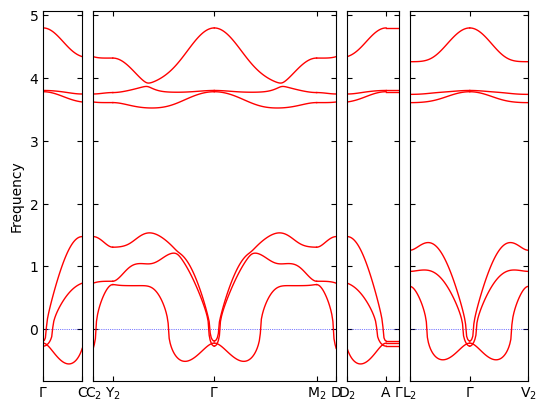

In [2]:
import os
from phonopy import load
import matplotlib.pyplot as plt

# Step 1: Load phonopy object with force constants
phonon = load(unitcell_filename='POSCAR',
              supercell_matrix=[[2, 0, 0], [0, 3, 0], [0, 0, 1]],  # Replace with yours
              primitive_matrix='auto',
              force_constants_filename='FORCE_CONSTANTS')

# Step 2: Set up the band path
# Phonopy can auto-generate the path based on your crystal structure
phonon.auto_band_structure(npoints=101)

# Step 3: Plot the band structure
phonon.plot_band_structure().show()

# Or save to file
# phonon.plot_band_structure().savefig('phonon_band.png', dpi=300)

<>:27: SyntaxWarning: "\G" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\G"? A raw string is also an option.
<>:27: SyntaxWarning: "\G" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\G"? A raw string is also an option.
<>:27: SyntaxWarning: "\G" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\G"? A raw string is also an option.
<>:27: SyntaxWarning: "\G" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\G"? A raw string is also an option.
C:\Users\furka\AppData\Local\Temp\ipykernel_19672\2862472734.py:27: SyntaxWarning: "\G" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\G"? A raw string is also an option.
  labels = ['K', '$\Gamma$', 'M', 'K','$\Gamma$']
C:\Users\furka\AppData\Local\Temp\ipykernel_19672\2862472734.py:27: SyntaxWarning: "\G" is an invalid escape sequence. 

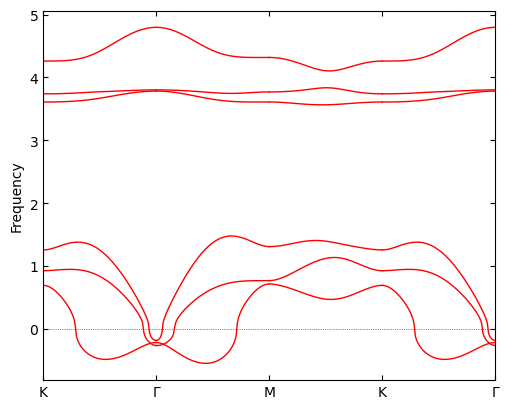

In [3]:
import numpy as np

# Function to generate points along a path
def make_band(start, end, npoints=100):
    """Generate npoints between start and end"""
    band = []
    for i in range(npoints):
        t = i / (npoints - 1)
        point = [(1-t)*s + t*e for s, e in zip(start, end)]
        band.append(point)
    return np.array(band)

# Define your high-symmetry points
X = [0.5, 0.0, 0.0]
G = [0.0, 0.0, 0.0]
M = [0.5, 0.5, 0.0]
Y = [0.0, 0.5, 0.0]

# Generate the paths with interpolated points
paths = [
    make_band(X, G, npoints=100),  # X to Gamma
    make_band(G, M, npoints=100),  # Gamma to M
    make_band(M, X, npoints=100),  # M to Gamma
    make_band(X, G, npoints=100)   # Gamma to Y
]

labels = ['K', '$\Gamma$', 'M', 'K','$\Gamma$']

phonon.run_band_structure(paths, labels=labels)
phonon.plot_band_structure().show()